## **Assignment: "The Gradient Optimizer" - Refined Backpropagation**

**The Scenario**

You have been promoted to Senior ML Engineer at "OptiTrain AI." Your previous MLP model worked, but it was slow to converge and often got stuck in "plateaus" (flat regions of the loss surface). Your task is to implement the modern refinements discussed in Lecture 17—specifically Momentum and Adam—to accelerate training and ensure the model reaches the global minimum.

## **Part 1:**

### **Question 1: The Physics of Learning**
You are training a network on a very "noisy" loss surface with many small local minima. You decide to add Momentum ($\gamma = 0.9$) to your update rule. What is the primary benefit here?

A) It effectively reduces the learning rate when gradients are high.

B) It helps the optimizer "dampen" oscillations and carry over velocity from previous steps to roll over small local bumps.

C) It makes the loss function convex.

D) It replaces the need for a bias term.

Please answer here

Answer = (B): Momentum carries a fraction of the previous update, which reduces zig-zag oscillations and helps the optimizer move through shallow local bumps/noisy regions faster.


### **Question 2: Symmetry Breaking**
What happens if you initialize every single weight in your MLP to exactly 0.0 before training?

A) The model will converge faster because it starts at the origin.

B) "Symmetry" is maintained: every hidden unit will compute the exact same gradient and update identically, effectively making the entire layer act like a single neuron.

C) The gradients will become infinite.

D) The model will only be able to solve the AND gate problem.

Please answer here

Answer = (B): With all weights initialized to zero, hidden neurons stay identical (same output and same gradient), so they update the same way and cannot learn diverse features.


### **Question 3: The "Co-adaptation" Problem**
During training, you apply Dropout with a rate of 0.5. How does this improve the generalizability of your model?

A) It reduces the number of parameters the model needs to save on disk.

B) It speeds up each training epoch since only half the neurons are being computed.

C) It prevents neurons from relying too heavily on specific neighbors, forcing each neuron to learn more robust, independent features.

D) It ensures the weights always remain positive.

Please answer here

Answer = (C): Dropout randomly disables neurons during training, so each neuron must learn useful signals without depending on specific neighbors, which improves generalization.


## **Part 2:**

### **Question 4: Velocity Calculation**
Suppose your current weight $\theta$ is 10.0.

Your current gradient $\nabla L$ is 2.0.

Your previous update $\Delta\theta_{t-1}$ was 1.0.

Learning rate $\eta = 0.1$ and Momentum coefficient $\gamma = 0.5$.

Calculate the new weight $\theta_{t+1}$.

Please answer here

Using momentum update:

Δθ_t = γΔθ_{t-1} + η∇L = (0.5)(1.0) + (0.1)(2.0) = 0.7

θ_{t+1} = θ_t - Δθ_t = 10.0 - 0.7 = 9.3

Answer: θ_{t+1} = 9.3

The current step combines both the previous velocity term and the current gradient term, then subtracts that total update from θ.


## **Part 3: Coding Challenge — Momentum vs. SGD**

In this section, you will modify a manual gradient descent loop to include a momentum term. You will see how much faster it reaches the target compared to standard SGD.

- **Update code line 17 and 27. Also vary gamma and observe the changes**

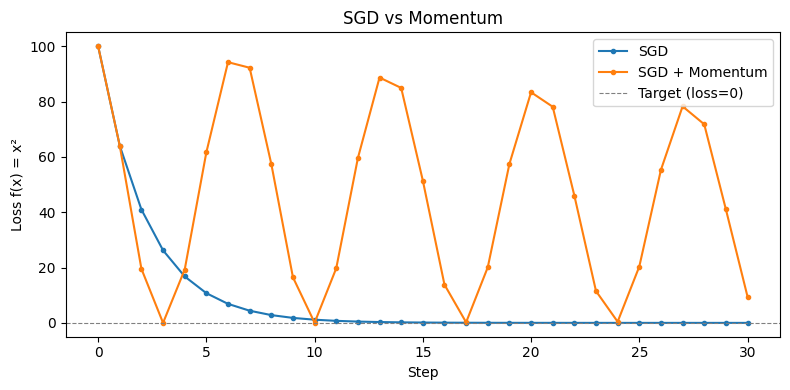

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def loss(x): return x**2
def grad(x): return 2*x

steps = 30
lr = 0.1
gamma = 0.99

# --- SGD ---
x_sgd = 10.0
sgd_path = [x_sgd]
for _ in range(steps):
    gradient = grad(x_sgd)
    ## FILL IN FOR x_sgd
    x_sgd = x_sgd - lr * gradient
    sgd_path.append(x_sgd)

# --- SGD with Momentum ---
x_mom = 10.0
v = 0.0
mom_path = [x_mom]
for _ in range(steps):
    gradient = grad(x_mom)
    ## FILL IN THE MOMENTUM FORMULA
    v = gamma * v + lr * gradient
    x_mom -= v
    mom_path.append(x_mom)

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot([loss(x) for x in sgd_path], label="SGD", marker="o", markersize=3)
plt.plot([loss(x) for x in mom_path], label="SGD + Momentum", marker="o", markersize=3)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="Target (loss=0)")
plt.xlabel("Step")
plt.ylabel("Loss f(x) = x²")
plt.title("SGD vs Momentum")
plt.legend()
plt.tight_layout()
plt.show()

Write your observations:

>What is the effect of momentum? What happens as you vary gamma?

Momentum adds velocity from previous steps, so optimization usually reaches low loss faster than plain SGD.

As γ increases (e.g., 0.8 to 0.99), updates become smoother and can move faster across flat regions, but too high γ may overshoot and oscillate near the minimum.

As γ decreases (e.g., toward 0), behavior becomes similar to plain SGD: slower but usually more stable with less overshoot.
